# Tarea 6 — Grafico Beeswarm (Enjambre de abejas)

> Con el `beeswarmtutorial.csv`, escoger un jugador y hacer el grafico de beeswarm con sus datos. Cambiar los datos de pases progresivos por otro nombre. Hacerlo primero de un jugador (como Thiago), y luego con la comparacion de otro jugador (como De Bruyne).

**Jugadores seleccionados (ambos MF, top 6 de la temporada en pases progresivos per90):**
- Individual: **Mateo Kovacic** (Chelsea) — 3ro en el ranking MF con ~8.02 per90
- Comparacion: **Mateo Kovacic** vs **Granit Xhaka** (Arsenal) — 4to en el ranking MF con ~7.95 per90

**Metrica:** Pases progresivos por cada 90 minutos

**Top 6 MF en pases progresivos per90:** 1. Thiago (9.88), 2. Kovacic (8.02), 3. Xhaka (7.95), 4. De Bruyne (7.56), 5. Bruno Fernandes (7.38), 6. Dani Ceballos (7.26)

In [1]:
# Importacion de librerias
# pandas: carga de DataFrame y calculo de la metrica por-90
# matplotlib: configuracion de figuras y temas de color
# seaborn: sns.swarmplot() — funcion central para graficos de distribucion beeswarm
# highlight_text: permite anotaciones de texto multicolor en matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Cargamos el dataset de pases progresivos de FBref para la Premier League 2020/21
# Columnas: Player, Pos, Squad, 90s (jornadas completas), Prog (pases progresivos totales)
df = pd.read_csv('../data/beeswarmTutorial11.csv')

# Limpiamos los nombres de jugadores (formato FBref: "Nombre\slug-url")
df['Player'] = df['Player'].str.split('\\', expand=True)[0]

# Constantes de tema visual — fondo oscuro con texto blanco
text_color = 'white'
background = '#313332'

df.head()

,Player,Pos,Squad,90s,Prog
0,Patrick van Aanholt,DF,Crystal Palace,11.7,76
1,Tammy Abraham,FW,Chelsea,10.6,11
2,Che Adams,FW,Southampton,19.0,38
3,Tosin Adarabioyo,DF,Fulham,18.0,36
4,Adrián,GK,Liverpool,2.0,0


In [2]:
# Normalizamos los pases progresivos totales por minutos jugados para obtener tasa por-90.
# Dividir el conteo bruto de Prog entre 90s elimina el sesgo por tiempo de juego:
# un jugador con 50 pases progresivos en 10 partidos y otro con 100 en 20 partidos
# tendran la misma tasa per90 (5.0), reflejando eficiencia real.
df['per90'] = df['Prog'] / df['90s']

# Aplicamos un umbral minimo de 6.5 jornadas completas (~585 minutos).
# Sin este filtro, jugadores con muy pocas apariciones producen tasas per90 extremas
# que son outliers estadisticos, no senales genuinas de rendimiento.
df = df[df['90s'] >= 6.5].reset_index()

# Ordenamos por per90 descendente y eliminamos porteros (Pos == 'GK')
# Los porteros rara vez intentan pases progresivos en la definicion de FBref
# y su presencia en el extremo bajo comprime la escala de los jugadores de campo.
df = df.sort_values(by='per90', ascending=False)
df = df[df['Pos'] != 'GK']

print(f"Jugadores de campo con 6.5+ jornadas: {len(df)}")
print(f"\nTop 10 en pases progresivos per90:")
print(df[['Player', 'Pos', 'Squad', 'per90']].head(10).to_string(index=False))

Jugadores de campo con 6.5+ jornadas: 284

Top 10 en pases progresivos per90:
                Player  Pos           Squad    per90
      Thiago Alcántara   MF       Liverpool 9.879518
Trent Alexander-Arnold   DF       Liverpool 8.512821
         Mateo Kovačić   MF         Chelsea 8.015267
          Granit Xhaka   MF         Arsenal 7.953216
      Jordan Henderson MFDF       Liverpool 7.613636
       Kevin De Bruyne   MF Manchester City 7.564103
          James Milner MFDF       Liverpool 7.500000
      Andrew Robertson   DF       Liverpool 7.467249
       James Rodríguez FWMF         Everton 7.443609
       Bruno Fernandes   MF  Manchester Utd 7.383178


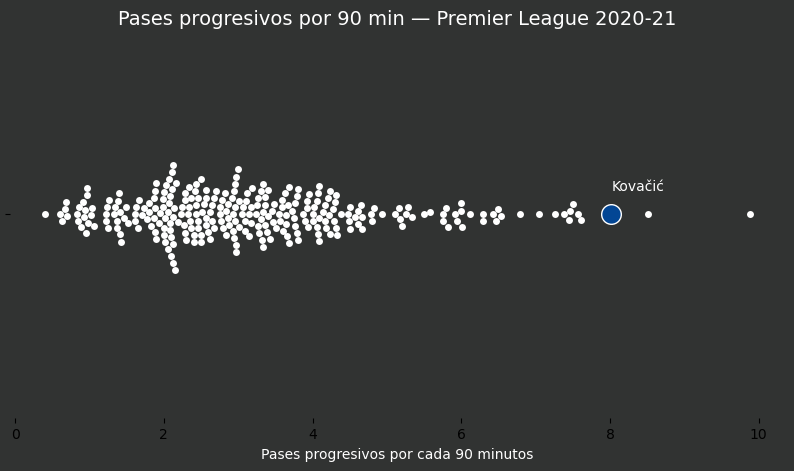

In [3]:
# --- Grafico beeswarm con Mateo Kovacic destacado ---
# Configuracion del tema oscuro
fig, ax = plt.subplots(figsize=(10, 5))
fig.set_facecolor(background)
ax.patch.set_facecolor(background)

mpl.rcParams['xtick.color'] = text_color
mpl.rcParams['ytick.color'] = text_color

# Cuadricula horizontal punteada para referencia visual
ax.grid(ls='dotted', lw=.5, color='lightgrey', axis='y', zorder=1)
for x in ['top', 'bottom', 'left', 'right']:
    ax.spines[x].set_visible(False)

# sns.swarmplot() renderiza un grafico beeswarm 1D a lo largo del eje x.
# Cada punto representa un jugador posicionado en su valor per90.
# El algoritmo "swarm" desplaza verticalmente los puntos superpuestos
# para evitar oclusion — a diferencia de un histograma, cada dato individual
# permanece visible e identificable.
sns.swarmplot(x='per90', data=df, color='white', zorder=1)

# Obtenemos el valor per90 exacto de Kovacic para posicionar el marcador
kovacic_per90 = df.loc[df['Player'] == 'Mateo Kovačić', 'per90'].values[0]

# Destacamos a Kovacic con un marcador mas grande y de color azul (Chelsea).
# y=0 es correcto porque swarmplot usa un eje categorico unico.
# zorder=2 asegura que el marcador destacado se renderice sobre la nube blanca.
plt.scatter(x=kovacic_per90, y=0, c='#034694', edgecolor='white', s=200, zorder=2)
plt.text(s='Kovačić', x=kovacic_per90, y=-0.002, c=text_color, fontsize=10)

plt.title('Pases progresivos por 90 min — Premier League 2020-21', c=text_color, fontsize=14)
plt.xlabel('Pases progresivos por cada 90 minutos', c=text_color)
plt.show()

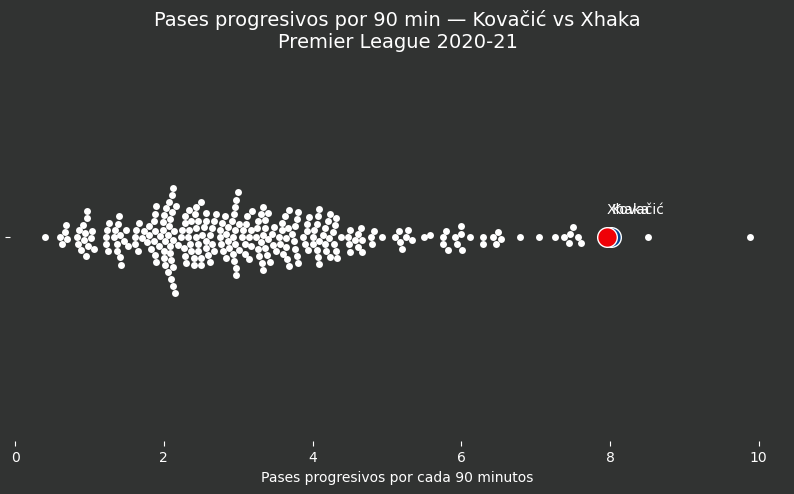

In [4]:
# --- Grafico beeswarm con comparacion: Mateo Kovacic vs Granit Xhaka ---
fig, ax = plt.subplots(figsize=(10, 5))
fig.set_facecolor(background)
ax.patch.set_facecolor(background)

mpl.rcParams['xtick.color'] = text_color
mpl.rcParams['ytick.color'] = text_color

ax.grid(ls='dotted', lw=.5, color='lightgrey', axis='y', zorder=1)
for x in ['top', 'bottom', 'left', 'right']:
    ax.spines[x].set_visible(False)

# Nube de distribucion completa en blanco
sns.swarmplot(x='per90', data=df, color='white', zorder=1)

# Obtenemos los valores per90 exactos de ambos jugadores
kovacic_per90 = df.loc[df['Player'] == 'Mateo Kovačić', 'per90'].values[0]
xhaka_per90 = df.loc[df['Player'] == 'Granit Xhaka', 'per90'].values[0]

# Destacamos a Kovacic en azul (Chelsea)
plt.scatter(x=kovacic_per90, y=0, c='#034694', edgecolor='white', s=200, zorder=2)
plt.text(s='Kovačić', x=kovacic_per90, y=-0.002, c=text_color, fontsize=10)

# Destacamos a Xhaka en rojo (Arsenal)
plt.scatter(x=xhaka_per90, y=0, c='#EF0107', edgecolor='white', s=200, zorder=2)
plt.text(s='Xhaka', x=xhaka_per90, y=-0.002, c=text_color, fontsize=10)

plt.title('Pases progresivos por 90 min — Kovačić vs Xhaka\nPremier League 2020-21',
          c=text_color, fontsize=14)
plt.xlabel('Pases progresivos por cada 90 minutos', c=text_color)
plt.show()

## Analisis del grafico beeswarm

El grafico beeswarm de pases progresivos por 90 minutos muestra la distribucion completa de todos los jugadores de campo de la Premier League 2020/21:

1. **Kovacic en el top 3 de mediocampistas:** Con aproximadamente 8.0 pases progresivos por cada 90 minutos, Mateo Kovacic se situa como el 2do mediocampista mas progresivo de la liga (solo por detras de Thiago). Su capacidad para conducir el balon y conectar lineas es evidente en este dato — Kovacic es reconocido por sus conducciones desde el mediocampo, y los pases progresivos confirman que no solo conduce sino que tambien pasa hacia adelante con eficacia.

2. **Xhaka practicamente al mismo nivel:** Granit Xhaka se ubica con ~7.95 per90, casi identico a Kovacic. Esto es particularmente interesante porque Xhaka tiene un perfil diferente: es un mediocampista mas estatico que Kovacic, pero compensa con una excelente capacidad de pase largo. Sus pases progresivos provienen mas de cambios de orientacion y pases verticales que de conducciones.

3. **Proximidad en la distribucion:** Ambos jugadores estan practicamente superpuestos en el extremo derecho de la distribucion. La diferencia entre ellos (~0.06 per90) es estadisticamente insignificante, lo que sugiere que ambos son igualmente efectivos para progresar el balon, aunque lo hacen de maneras distintas.

4. **Contexto de la distribucion completa:** La mayoria de jugadores se concentra entre 1 y 5 pases progresivos per90. Tanto Kovacic como Xhaka se situan en el top 2% de la liga, muy por encima de la mediana. Solo Thiago Alcantara (~9.9) los supera de forma clara entre los mediocampistas puros.

**Conclusion:** El grafico beeswarm revela que Kovacic y Xhaka fueron dos de los mediocampistas mas progresivos de la Premier League 2020/21. Pese a tener estilos de juego muy diferentes (Kovacic mas conductor, Xhaka mas pasador), su output en pases progresivos es practicamente identico, lo que demuestra que hay multiples vias para ser un mediocampista que avanza el balon hacia zonas peligrosas.